## 复现运行与源码对齐说明

> 当前 clean 代码：`src/01_extract_features.py`  
> 原始代码：`特征提取源码未公开`  
> 执行规范：paper-reproduction；原始仓库只读。  
> 本手册已完成 Notebook JSON 与代码单元静态检查。涉及数据的单元需按 `DATA.md` 准备数据后，从头运行以生成本机结果。

本手册保留六层学习结构：纯净代码、逐行详解、语法表、数据流角色、物理含义与真实数据图、踩坑记录。论文与源码不一致处以源码为复现基准并单独说明。

# PINN4SOH 特征提取

> 本手册按照 `src/01_extract_features.py` 的**代码书写顺序**逐段解读。
> 代码文件已去除所有注释，适合边看纯净代码边对照学习。
>
> 每个代码块解释三件事：**语法（syntax）、功能（function）、逻辑（logic）**。

---

## 目录

| 章节 | 对应代码行 | 内容 |
|------|:----------:|------|
| [1. 导入依赖库](#sec1) | 1-6 | 6 个 import 语句的语法与用途 |
| [2. 路径设置与外部模块导入](#sec2) | 8-15 | `os.path.join` / `sys.path` / `from...import` |
| [3. 配置参数](#sec3) | 17-29 | 输入输出路径、CC/CV 数据窗口 |
| [4. compute_features() 函数](#sec4) | 32-74 | 核心算法：16 个特征逐个拆解 |
| [5. extract_all_features() 函数](#sec5) | 77-139 | 遍历循环、异常处理、DataFrame 构建 |
| [6. 主程序入口](#sec6) | 142-171 | `if __name__ == ''__main__''` 与完整执行流程 |




---

### 物理背景：CC/CV 充电协议

锂离子电池标准充电分两阶段：

```
CC (Constant Current / 恒流充电):
  - 电流恒定 ~4A，电压从 3.5V 缓慢升到 4.2V
  - 论文截取V-T图电压区间 [4.0, 4.2]V -> 高 SOC 区域，对老化最敏感

CV (Constant Voltage / 恒压充电):
  - 电压锁死在 4.2V，电流从 ~4A 指数衰减到 ~0.1A
  - 论文截取C-T图电流区间 [0.5, 0.1]A -> 电流衰减尾段，编码老化信息
```

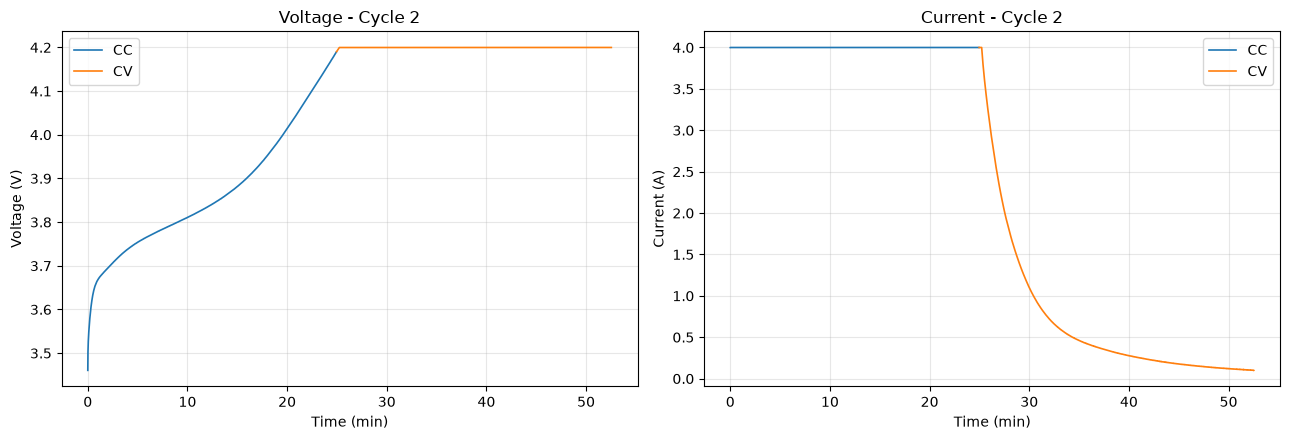


### 16 个特征概览

| # | CC 阶段（电压-based） | # | CV 阶段（电流-based） |
|---|----------------------|---|----------------------|
| 1 | voltage mean | 9 | current mean |
| 2 | voltage std | 10 | current std |
| 3 | voltage kurtosis | 11 | current kurtosis |
| 4 | voltage skewness | 12 | current skewness |
| 5 | CC Q (Ah) | 13 | CV Q (Ah) |
| 6 | CC charge time (s) | 14 | CV charge time (s) |
| 7 | voltage slope (V/s) | 15 | current slope (A/s) |
| 8 | voltage entropy | 16 | current entropy |

**Target:** capacity (discharge capacity, Ah)

> **来源**：Wang, F. et al. "Physics-informed neural network for lithium-ion battery degradation stable modeling and prognosis." *Nature Communications* 15, 4332 (2024).

---

## 1. 导入依赖库 <a id="sec1"></a>
> **对应 `extract_features_clean.py` 第 1-6 行**

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from scipy import integrate as scipy_integrate
import os
import sys



### 1.1 逐行语法与功能

**`import numpy as np`**（第 1 行）
- `import X` -> 导入模块 X
- `as np` -> 起别名。`numpy` 太长，社区约定用 `np`
- 功能：数值计算 —— `np.mean()`, `np.std()`, `np.polyfit()`, `np.histogram()`

**`import pandas as pd`**（第 2 行）
- `as pd` -> 社区约定别名
- 功能：数据处理 —— `pd.DataFrame()` 构建表格, `df.to_csv()` 写文件

**`from scipy import stats as scipy_stats`**（第 3 行）
- `from X import Y` -> 从包 X 中只导入子模块 Y（不是全部导入）
- `as scipy_stats` -> 起别名，避免与变量名冲突
- 功能：`kurtosis()` 峰度, `skew()` 偏度, `entropy()` 熵

**`from scipy import integrate as scipy_integrate`**（第 4 行）
- 同上的 `from...import...as` 结构
- 功能：`trapezoid()` 梯形数值积分 -> 计算充电容量

**`import os`**（第 5 行）
- Python 内置模块（标准库），无需 pip 安装
- 功能：`os.path.join()` 跨平台路径拼接

**`import sys`**（第 6 行）
- Python 内置模块
- 功能：`sys.path.insert()` 扩展模块搜索路径

### 1.2 逻辑

这 6 个 import 覆盖了脚本的所有需求：

| 需求 | 依赖 |
|------|------|
| 数值计算 | `numpy`, `scipy.stats`, `scipy.integrate` |
| 数据处理 | `pandas` |
| 文件系统 | `os`, `sys` |


---

## 2. 路径设置与外部模块导入 <a id="sec2"></a>

> **对应 `extract_features_clean.py` 第 8-15 行**

In [ ]:
PREPROCESSING_LIB = os.path.join(
    os.environ.get("PINN4SOH_RAW_PROJECT_ROOT", "../data/raw"),
    r"物理信息神经网络用于锂离子电池退化稳定建模与预测-西安交通大学",
    r"Battery-dataset-preprocessing-code-library-main",
    r"Battery-dataset-preprocessing-code-library-main"
)
sys.path.insert(0, PREPROCESSING_LIB)
from XJTUBatteryClass import Battery



### 2.1 逐行语法

**`os.path.join(a, b, c, ...)`**（第 8-12 行）
- 拼接路径片段，**自动使用当前系统的分隔符**
- Windows -> `\`，Linux -> `/`
- 比硬编码 `"a\b\c"` 跨平台兼容

**`r"..."` -> 原始字符串（Raw String）**（第 9-11 行）
- `r` 前缀：不处理字符串中的反斜杠转义
- `r"\n"` -> 两个字符 `\` 和 `n`；普通 `"\n"` -> 换行符
- Windows 路径含大量反斜杠，加 `r` 防止意外转义

**`sys.path` -> Python 搜索模块的路径列表**（第 14 行）
- 执行 `import X` 时，Python 按 `sys.path` 中目录顺序找 `X.py`
- 默认包含：当前目录 -> PYTHONPATH -> 标准库 -> site-packages
- `sys.path.insert(0, path)` -> 把自定义路径**插到最前面**（索引 0），确保优先命中

**`from XJTUBatteryClass import Battery`**（第 15 行）
- 从 `XJTUBatteryClass.py` 中导入 `Battery` 类
- 该文件不在 pip 安装路径，所以必须先 `sys.path.insert` 添加其所在目录

### 2.2 逻辑

```
extract_features.py
    | 想 import
XJTUBatteryClass.py  <- 在另一个文件夹里
    | Python 默认搜不到
需要 sys.path.insert() 告诉 Python 去哪里找
```

`Battery` 类封装了对 .mat 文件的底层操作：
- `scipy.io.loadmat` 读取 MATLAB 格式
- 自动识别 CC/CV 阶段边界
- `get_CC_value()` 按电压范围截取 CC 数据
- `get_CV_value()` 按电流范围截取 CV 数据

> **注意**：`PREPROCESSING_LIB` 是这台电脑上的自定义路径。换电脑需修改。

---

## 3. 配置参数 <a id="sec3"></a>

> **对应 `extract_features_clean.py` 第 17-29 行**

In [ ]:
MAT_PATH = os.path.join(
    os.environ.get("PINN4SOH_RAW_PROJECT_ROOT", "../data/raw"),
    r"物理信息神经网络用于锂离子电池退化稳定建模与预测-西安交通大学",
    r"Battery Dataset\Battery Dataset\Batch-1",
    r"2C_battery-1.mat"
)

OUTPUT_DIR = r"../outputs"
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "2C_battery-1_features.csv")

CC_VOLTAGE_RANGE = [4.0, 4.199]

CV_CURRENT_RANGE = [0.5, 0.1]



### 3.1 参数一览

| 变量 | 类型 | 含义 |
|------|------|------|
| `MAT_PATH` | `str` | 输入 .mat 文件完整路径 |
| `OUTPUT_DIR` | `str` | 输出 CSV 的目标文件夹 |
| `OUTPUT_CSV` | `str` | 输出 CSV 完整路径 |
| `CC_VOLTAGE_RANGE` | `list` | CC 电压窗口 `[下限, 上限]` |
| `CV_CURRENT_RANGE` | `list` | CV 电流窗口 `[上限, 下限]` |

**把参数放在顶部的好处**：修改时不用翻代码；一目了然；避免硬编码散落各处。

### 3.2 CC 窗口 [4.0, 4.199] 的来源

论文原文："*The CC data between V_end - 0.2 V and V_end*"
- `V_end` = CC 阶段结束电压，理论值 4.2V
- `V_end - 0.2` = 4.0V -> 标准窗口 [4.0, 4.2]
- **为什么用 4.199 而非 4.2？** ~4.2V 时已进入 CV 阶段（电压恒定），上限写 4.2 会混入 CV 数据。4.199 是工程上的"安全余量"。

### 3.3 CV 窗口 [0.5, 0.1] 的来源

CV 阶段电流从 ~4A 指数衰减到 ~0.1A。取 [0.5, 0.1] 是因为：
- 衰减尾段的曲线形状对老化最敏感
- 窗口太宽 -> 特征粗糙；太窄 -> 信息不足

**为什么是 [高, 低] 而非 [低, 高]？** CV 电流从高往低衰减，`get_CV_value()` 的 `current_range` 参数语义为 `[起始值, 截止值]`。

---

## 4. compute_features() 函数 —— 核心算法 <a id="sec4"></a>

> **对应 `extract_features_clean.py` 第 32-74 行**

输入一个循环的 CC/CV 时序数据 -> 输出 16 个统计特征。

### 4.1 函数签名（第 32-34 行）

In [ ]:
def compute_features(voltage_cc, current_cc, time_cc,
                     current_cv, voltage_cv, time_cv):
    features = {}



**语法要点：**

- `def` -> 定义函数的关键字
- `compute_features` -> 函数名，蛇形命名法（snake_case，动词在前）
- `(参数1, 参数2, ...)` -> 6 个 NumPy 数组参数，逗号分隔，括号内可跨行
- `features = {}` -> 空字典，准备存 16 个键值对。eg.`'voltage mean'`是键，所对应计算出的值为`np.mean(voltage_cc)`

**Note**：

`2C_battery-1.mat`文件中的一个数据字段名`relative_time_min` ，它的存储单位是**分钟**，不是秒。

因此输出时：
- 时间类特征：`x 60`（分钟 -> 秒）
- 容量积分：`/ 60`（A·min -> Ah）

### 4.2 特征 1-4：CC 阶段基础统计量（第 36-42 行）

**代码结构片段（教学展示，不单独执行）**

```python
    features['voltage mean'] = np.mean(voltage_cc)

    features['voltage std'] = np.std(voltage_cc)

    features['voltage kurtosis'] = scipy_stats.kurtosis(voltage_cc, fisher=True)

    features['voltage skewness'] = scipy_stats.skew(voltage_cc)
```

**四行代码，四个"描述性统计"指标：**

| 特征 | 函数 | 物理含义 |
|------|------|----------|
| `voltage mean` | `np.mean()` — 算术平均 | 电压平均水平。老化电池内阻上升，同电流下电压更高。 |
| `voltage std` | `np.std()` — 标准差（ddof=0） | 电压离散度。老化导致电化学不均匀，从而使得波动增大。 |
| `voltage kurtosis` | `scipy_stats.kurtosis(fisher=True)` — Fisher 峰度 | 分布"尖峭度"。正态=0，>0 更尖，<0 更扁。 |
| `voltage skewness` | `scipy_stats.skew()` — 偏度 | 分布偏斜。>0 右偏（尾在右），<0 左偏。 |

**为什么统计量能反映老化？** 电池老化后 CC 充电曲线上移（内阻 ↑ -> IR 降 ↑），曲线形状同时变化。这四个量从不同维度量化形状变化。



**代码结构片段（教学展示，不单独执行）**

```python
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.join(
    os.environ.get("PINN4SOH_RAW_PROJECT_ROOT", "../data/raw"),
    r"物理信息神经网络用于锂离子电池退化稳定建模与预测-西安交通大学",
    r"Battery-dataset-preprocessing-code-library-main",
    r"Battery-dataset-preprocessing-code-library-main"
))
from XJTUBatteryClass import Battery
import matplotlib.pyplot as plt
import numpy as np

battery = Battery(os.environ.get("PINN4SOH_XJTU_MAT_PATH", "../data/raw/XJTU/Batch-1/2C_battery-1.mat"))

# 打印关键数值对比
print('=' * 65)
print(f'{"Cycle":>8}  {"voltage mean":>13}  {"voltage std":>12}  {"CC time(min)":>14}')
print('-' * 65)
for cycle in cycles:
    V_cc = battery.get_CC_value(cycle, 'voltage_V', voltage_range=[4.0, 4.199])
    t_cc = battery.get_CC_value(cycle, 'relative_time_min', voltage_range=[4.0, 4.199])
    print(f'{cycle:>8}  {np.mean(V_cc):>13.5f}  {np.std(V_cc):>12.5f}  {t_cc[-1]-t_cc[0]:>14.3f}')
print('=' * 65)
print('→ 电压均值 ↑（曲线上移），CC 充电时间 ↓（容量衰减）')
```

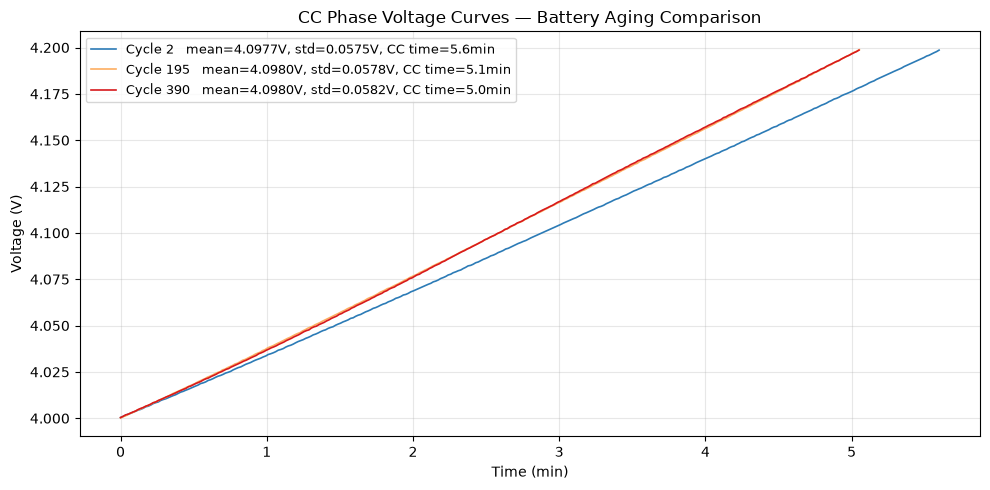

### 4.3 特征 5：CC Q —— CC 阶段充电容量（第 44 行）

**代码结构片段（教学展示，不单独执行）**

```python
    features['CC Q'] = scipy_integrate.trapezoid(current_cc, time_cc) / 60.0
```

**公式：** Q<sub>CC</sub> = (1/60) · ∫ I(t) dt

**语法拆解：**
- `scipy_integrate.trapezoid(y, x)` -> 梯形数值积分
  - 原理：N 个小梯形面积之和 ~ 曲线下面积
  - 每个梯形面积 = (y<sub>i</sub> + y<sub>i+1</sub>)/2 · Δx
- `/ 60.0` -> 单位转换：A·min / 60 = A·h = **Ah**

**物理含义：** C-T图中，CC 阶段在 [4.0, 4.2]V 内充入的电量。健康电池多，老化电池少。


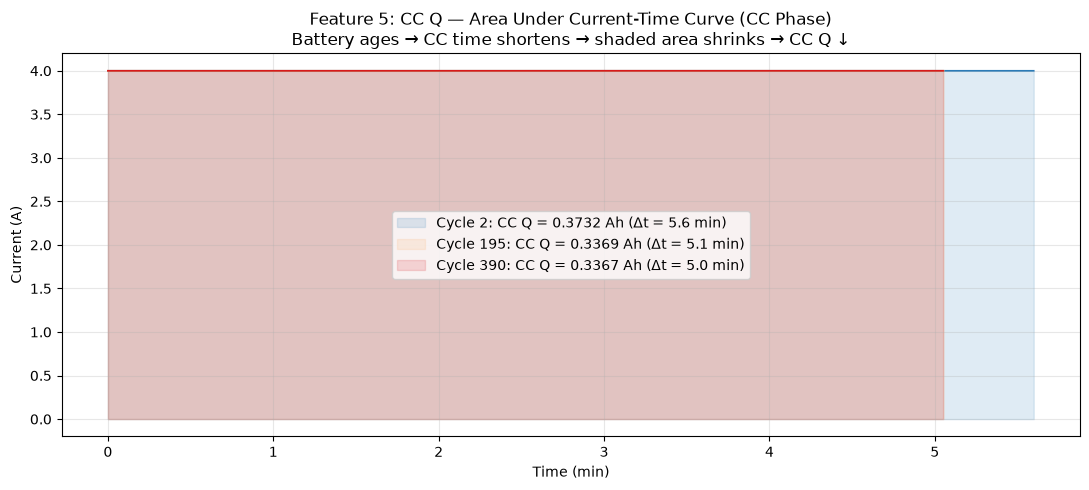

### 4.4 特征 6：CC charge time —— CC 阶段持续时间（第 46 行）

**代码结构片段（教学展示，不单独执行）**

```python
    features['CC charge time'] = (time_cc[-1] - time_cc[0]) * 60.0
```

**公式：** T<sub>CC</sub> = (t<sub>last</sub> - t<sub>first</sub>) x 60

**语法拆解：**
- `time_cc[-1]` -> **负索引**：`-1` = 最后一个元素
- `time_cc[0]` -> 第一个元素
- `* 60.0` -> 分钟转秒

**负索引速查：** `arr[-1]` = 最后, `arr[-2]` = 倒数第二, ..., `arr[0]` = 第一个。

**物理含义：** V-T图中，电压从 4.0V 爬到 4.199V 的耗时（秒）。由于电池老化，使得内阻大，从而电压升得快，CC 时间缩短。

### 4.5 特征 7：voltage slope —— 电压斜率（第 48-49 行）

**代码结构片段（教学展示，不单独执行）**

```python
    slope_v_per_min, _ = np.polyfit(time_cc, voltage_cc, 1)
    features['voltage slope'] = slope_v_per_min / 60.0
```

**公式：** 最小二乘法拟合 V = k·t + b，k 为斜率。

**语法拆解：**
- `np.polyfit(x, y, deg)` -> 多项式拟合
  - `deg=1` -> 线性拟合（1 次多项式）
  - 返回 `[斜率, 截距]`
- `slope_v_per_min, _ = np.polyfit(...)` -> **元组解包（Tuple Unpacking）**
  - 第一个值赋给 `slope_v_per_min`
  - `_` -> Python 约定："我不需要这个值"（占位符）
- `/ 60.0` -> V/min -> V/s

**物理含义：** V-T 图的CC 段中，电压上升速率。老化电池 CC 阶段电压升得更快，导致斜率更大。

### 4.6 特征 8：voltage entropy —— 电压分布熵（第 51-53 行）

**代码结构片段（教学展示，不单独执行）**

```python
    v_hist, _ = np.histogram(voltage_cc, bins=len(voltage_cc), density=True)
    v_hist = v_hist[v_hist > 0]
    features['voltage entropy'] = scipy_stats.entropy(v_hist)
```

**公式：** H = -Σ p<sub>i</sub> · log(p<sub>i</sub>)（香农熵）

**三步拆解：**

1. `np.histogram(data, bins=len(data), density=True)` -> 做直方图
   - `bins=len(data)` -> **关键参数！** 每个数据点一个 bin = 经验分布
   - `density=True` -> 归一化为概率密度（总面积=1）
   - 返回 `(概率密度数组, bin边界数组)`

2. `v_hist = v_hist[v_hist > 0]` -> **布尔索引（Boolean Indexing）**
   - `v_hist > 0` 生成 `[True, False, True, ...]` 布尔数组
   - 用布尔数组索引 -> 只保留 True 位置的元素
   - 目的：去除概率为零的 bin（log(0) 无定义）

3. `scipy_stats.entropy(v_hist)` -> 计算香农熵
   - 熵大 -> 分布均匀（电压分散）
   - 熵小 -> 分布集中（电压在某区聚集）

**理解：**
把电压值本身从小到大排序、分桶（划分电压小区间）、统计每个电压小区间有多少个数据点。然后算出每个电压小区间出现数据点的"概率密度" 

**⚠️ `bins=len(data)` vs `bins=''auto''`：**
- `''auto''` -> 约 10 个 bin，熵 ~ 2.3（**错误**）
- `len(data)` -> 每个点一个 bin（约200个），熵 ~ 5-6（与原文 CSV 一致）
- 这是调试中发现的关键差异

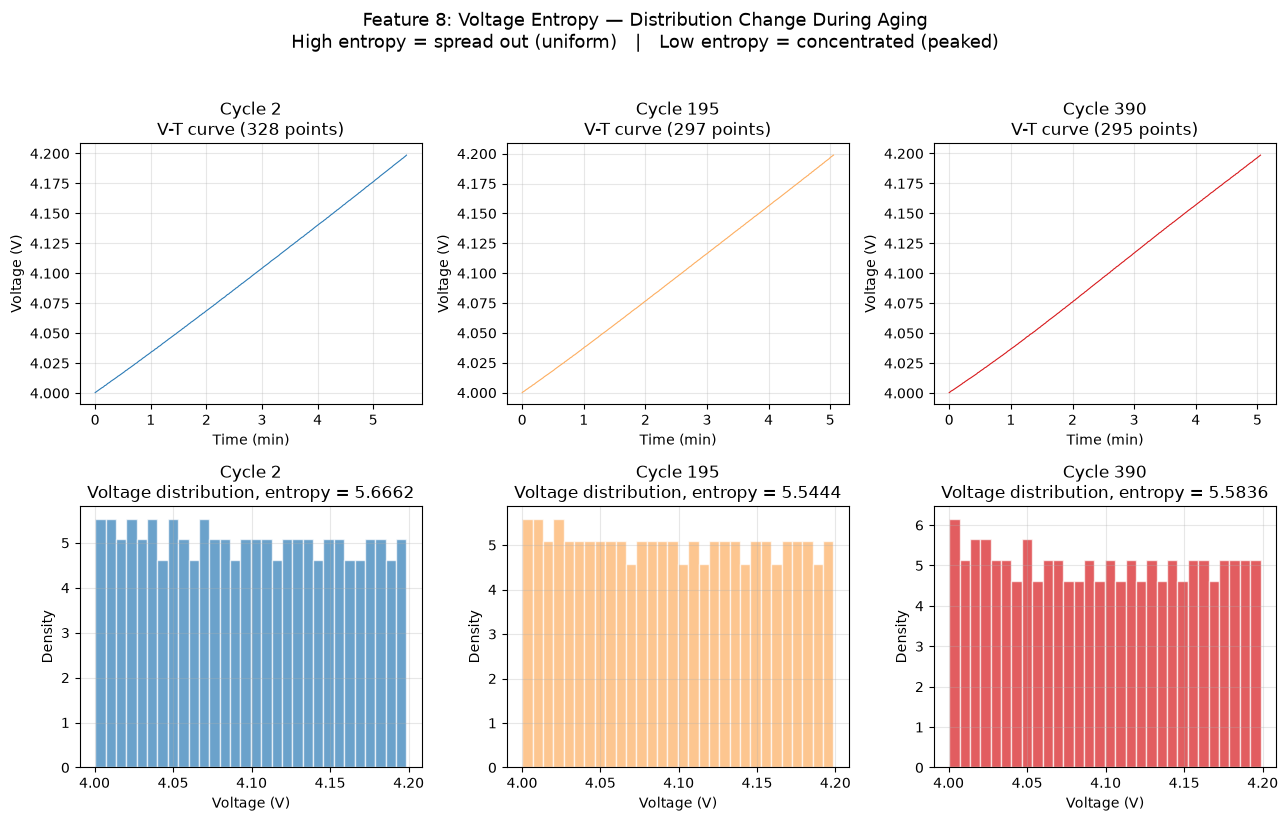


### 4.7 特征 9-16：CV 阶段 —— 电流统计（第 55-74 行）

**代码结构片段（教学展示，不单独执行）**

```python
    features['current mean'] = np.mean(current_cv)

    features['current std'] = np.std(current_cv)

    features['current kurtosis'] = scipy_stats.kurtosis(current_cv, fisher=True)

    features['current skewness'] = scipy_stats.skew(current_cv)

    features['CV Q'] = scipy_integrate.trapezoid(current_cv, time_cv) / 60.0

    features['CV charge time'] = (time_cv[-1] - time_cv[0]) * 60.0

    slope_c_per_min, _ = np.polyfit(time_cv, current_cv, 1)
    features['current slope'] = slope_c_per_min / 60.0

    c_hist, _ = np.histogram(current_cv, bins=len(current_cv), density=True)
    c_hist = c_hist[c_hist > 0]
    features['current entropy'] = scipy_stats.entropy(c_hist)

    return features
```

**与 CC 特征的对称关系：**

| CC 阶段（特征 1-8） | CV 阶段（特征 9-16） |
|---------------------|---------------------|
| 输入：`voltage_cc` | 输入：`current_cv` |
| 电压的 mean/std/kurtosis/skew | 电流的 mean/std/kurtosis/skew |
| 积分 I·dt（电压范围） | 积分 I·dt（电流范围） |
| 电压-时间斜率 | 电流-时间斜率 |
| 电压分布熵 | 电流分布熵 |

**公式完全对称，只是变量名从 `voltage_cc` 换成 `current_cv`。**

**第 74 行：`return features`** -> 返回含 16 个键值对的字典。调用方拿到后转为 DataFrame 的一行。

---

## 5. extract_all_features() 函数 —— 批量处理 <a id="sec5"></a>

> **对应 `extract_features_clean.py` 第 77-139 行**

`compute_features()` 只处理**一个**循环。这个函数遍历**所有**循环，逐一调用它，并组装成 DataFrame。

### 5.1 函数签名与容量获取（第 77-88 行）

In [ ]:
def extract_all_features(battery):
    n_cycles = battery.data.shape[1]        # 总循环数
    print(f"Battery name: {battery.battery_name}")    # 电池编号
    print(f"Cycle life:   {battery.cycle_life}")      # 寿命（圈数）
    print(f"Total cycles: {n_cycles}")                 # 数据文件里的总圈数
    print(f"Description:  {battery.description}")      # 备注信息
    print()

    capacity_all = battery.get_capacity()

    all_features = []
    skipped_cycles = []





**含义：**
- `battery.data.shape[1]`  :	`.mat` 数据是 (变量数, 循环数)，取第二维 = 总共有多少圈充放电
- `battery.battery_name` : 如 '2C_battery-1'，标识是哪块电池
- `battery.cycle_life`	 : 电池的标定寿命（比如 200 圈后容量降到 80% 以下）
- `battery.description`  ：数据集的描述文字
- `capacity_all = battery.get_capacity()`  : 返回一个数组，长度 = `n_cycles`，每个元素是对应循环的放电容量 (Ah)`capacity_all = [cap_cycle1, cap_cycle2, ..., cap_cycleN]`。容量是 SOH 预测的目标值 y——16 个特征是 x，容量是 y。后面训练 PINN 就是用这些 (特征, 容量) 配对数据。
- `all_features = []`   : 存每个循环的特征字典 [{...}, {...}, ...]
- `skipped_cycles = []`  : 存跳过的循环及其原因 [(3, "insufficient data"), (7, "error msg"), ...]

**语法要点：**

- `battery.data.shape[1]` -> `.shape` 返回 `(行数, 列数)`，`[1]` 取列数 = 总循环数
- `f"..."` -> **f-string**：`{变量}` 被替换为变量值
- `capacity_all = battery.get_capacity()` -> 返回 shape=(n_cycles,) 的一维数组




### 5.2 主循环（第 90-122 行）

**代码结构片段（教学展示，不单独执行）**

```python
    for cycle in range(1, n_cycles + 1):
        try:
            voltage_cc = battery.get_CC_value(cycle, 'voltage_V',
                                              voltage_range=CC_VOLTAGE_RANGE)
            current_cc = battery.get_CC_value(cycle, 'current_A',
                                              voltage_range=CC_VOLTAGE_RANGE)
            time_cc    = battery.get_CC_value(cycle, 'relative_time_min',
                                              voltage_range=CC_VOLTAGE_RANGE)

            current_cv = battery.get_CV_value(cycle, 'current_A',
                                              current_range=CV_CURRENT_RANGE)
            voltage_cv = battery.get_CV_value(cycle, 'voltage_V',
                                              current_range=CV_CURRENT_RANGE)
            time_cv    = battery.get_CV_value(cycle, 'relative_time_min',
                                              current_range=CV_CURRENT_RANGE)

            if len(voltage_cc) < 3 or len(current_cv) < 3:
                skipped_cycles.append((cycle, "insufficient data points"))
                continue

            features = compute_features(voltage_cc, current_cc, time_cc,
                                        current_cv, voltage_cv, time_cv)

            features['capacity'] = capacity_all[cycle - 1]

            all_features.append(features)

        except Exception as e:
            skipped_cycles.append((cycle, str(e)))
            continue

        if cycle % 50 == 0:
            print(f"  Processed {cycle}/{n_cycles} cycles...")
```

**逻辑**

      每一圈充电数据   
            |        
      切出 CC/CV 两段 
            |         
     算出 16 个统计特征
            |         
         拼上容量      
            |         
         装进列表      
            |         
     出错了就跳过记一笔 
            |          
     每 50 圈汇报一次进度


**主循环的结构**

`for cycle in range(1, n_cycles + 1):  `   ← 从第 1 圈遍历到最后一圈

    try:

    [1] 取数据  (92-104 行)
        # CC 阶段：按电压窗口 [4.0, 4.199]V 切
voltage_cc = battery.get_CC_value(cycle, 'voltage_V',      voltage_range=[4.0, 4.199])

current_cc = battery.get_CC_value(cycle, 'current_A',      voltage_range=[4.0, 4.199])

time_cc    = battery.get_CC_value(cycle, 'relative_time_min', voltage_range=[4.0, 4.199])

       # CV 阶段：按电流窗口 [0.5, 0.1]A 切
current_cv = battery.get_CV_value(cycle, 'current_A',      current_range=[0.5, 0.1])

voltage_cv = battery.get_CV_value(cycle, 'voltage_V',      current_range=[0.5, 0.1])

time_cv    = battery.get_CV_value(cycle, 'relative_time_min', current_range=[0.5, 0.1])

一个循环取 6 组数据，三组来自 CC 段（电压限定），三组来自 CV 段（电流限定）




        [2] 数据检查 (106-108 行)          
if len(voltage_cc) < 3 or len(current_cv) < 3:

skipped_cycles.append((cycle, "insufficient data points"))

continue   #跳过这一圈，进入下一个 cycle
    
少于 3 个数据点时无法计算标准差、峰度、斜率等统计量，直接跳过。


        {3} 算特征  (110-115 行)
features = compute_features(voltage_cc, current_cc, time_cc,
                            current_cv, voltage_cv, time_cv)  # 产出 16 个统计量

features['capacity'] = capacity_all[cycle - 1]  # 加上第 17 列：目标值

all_features.append(features)                   # 装进结果列表




    except:
    
        [4] 异常处理 (117-119 行)

except Exception as e:

skipped_cycles.append((cycle, str(e)))

continue

任何一圈出问题（数据缺失、格式异常等），记录原因后跳过继续跑，不因个别坏圈中断整个提取


**语法逐行拆解：**

**第 87-88 行：`all_features = []` / `skipped_cycles = []`**
- 两个空列表 -> `all_features` 存成功结果，`skipped_cycles` 存失败记录

**第 90 行：`for cycle in range(1, n_cycles + 1):`**
- `range(start, stop)` -> 生成 start, start+1, ..., stop-1
- 例：`range(1, 4)` -> `1, 2, 3`（**不含 4**！）
- `n_cycles + 1` -> 确保包含最后一个循环
- `cycle` 从 1 开始 -> Battery 类用 1-based 编号

**第 91 行：`try:`** -> 开始异常保护块

**第 92-97 行：获取 CC 数据**
- `battery.get_CC_value(cycle, field, voltage_range=...)` -> 三个调用分别取 V / I / t
- 三者**逐点对齐**：同一索引 = 同一时刻

**第 99-104 行：获取 CV 数据** -> 同理，按电流范围截取

**第 106-108 行：有效性检查**
- `if len(...) < 3` -> 少于 3 个点无法做统计 + 梯形积分至少需 2 点
- `continue` -> 跳过本次循环，进入下一个 cycle

**第 110-111 行：调用 `compute_features()`** -> 传入 6 个数组，得到 16 个特征

**第 113 行：添加容量**
- `capacity_all[cycle - 1]` -> **索引差 1！**
  - `cycle` 从 1 开始（第 1 循环）
  - 数组索引从 0 开始 -> 所以第 N 循环在 `capacity_all[N-1]`

**第 115 行：`all_features.append(features)`** -> 追加到结果列表

**第 117-119 行：`except Exception as e:`**
- 捕获 try 块中任何异常，不崩溃
- 记录 `(循环号, 错误信息)`，然后 `continue`

**第 121-122 行：进度打印**
- `if cycle % 50 == 0` -> `%` 是取模运算符
- 每 50 个循环打印一次，避免刷屏


### 5.3 构建 DataFrame（第 129-139 行）

**代码结构片段（教学展示，不单独执行）**

```python
    df = pd.DataFrame(all_features)
    column_order = [
        'voltage mean', 'voltage std', 'voltage kurtosis', 'voltage skewness',
        'CC Q', 'CC charge time', 'voltage slope', 'voltage entropy',
        'current mean', 'current std', 'current kurtosis', 'current skewness',
        'CV Q', 'CV charge time', 'current slope', 'current entropy',
        'capacity'
    ]
    df = df[column_order]

    return df
```

**核心：** 把主循环中保存的列表转成表格

**语法要点：**

- `pd.DataFrame(all_features)` -> 从字典列表创建 DataFrame
  - 每个字典 = 一行，键 = 列名
- `df[column_order]` -> **列重排序**
  - 传入列名列表，按此顺序重新排列
  - 保证输出 CSV 的列顺序与论文一致（CC -> CV -> capacity）
- `return df` -> 返回 DataFrame 对象给主程序

---

## 6. 主程序入口 <a id="sec6"></a>

> **对应 `extract_features_clean.py` 第 142-171 行**

In [ ]:
import sys
from pathlib import Path
CLEAN = Path(r'../src')
sys.path.insert(0, str(CLEAN))
from module_loader import load_clean_module
module = load_clean_module('01_extract_features.py', 'notebook_feature')
Battery = module.load_battery_class()
battery = Battery(str(module.XJTU_MAT_PATH))
df, skipped = module.extract_all_features(battery)
print(f'形状: {df.shape}, 跳过: {skipped}')
df.head()

### 6.1 `if __name__ == ''__main__''` —— 理解执行入口

这是 Python 中**最重要却最容易被忽略**的语法。

**`__name__` 是什么？**
- 每个 .py 文件都有一个内置变量 `__name__`
- **直接运行**时 -> `__name__` = `''__main__''`
- **被导入**时 -> `__name__` = 文件名（如 `''extract_features''`）

**这行代码的含义：**
```python
if __name__ == ''__main__'':   # 只有当我是被直接运行时
    ...                         # 才执行以下代码
```

**为什么需要？** 如果别人 `import extract_features` 只想复用 `compute_features()`，没有这行保护的话，导入时就会自动跑完整流程（耗时且无意义）。

### 6.2 三步执行流程

主程序用 `[1/3]` `[2/3]` `[3/3]` 标注清晰的三步：

```
[1/3] 加载数据 -> Battery(MAT_PATH)
        +-- 内部调用 scipy.io.loadmat 解析 .mat 文件

[2/3] 提取特征 -> df = extract_all_features(battery)
        +-- 遍历 390 循环 -> compute_features() x 390 -> DataFrame

[3/3] 保存 CSV -> df.to_csv(OUTPUT_CSV, index=False)
        +-- index=False = 不写入行号列（原论文 CSV 没有这列）
```

### 6.3 语法细节速查

| 表达式 | 含义 |
|--------|------|
| `os.path.basename(path)` | 从完整路径取文件名 |
| `Battery(path)` | 创建对象，解析 .mat |
| `df.to_csv(path, index=False)` | 写 CSV，不写行号 |
| `df.shape` | `(行数, 列数)` |
| `df.head()` | 前 5 行 |
| `df.describe()` | 统计摘要（count/mean/std/min/max/分位数） |

### 6.4 完整数据流

```
2C_battery-1.mat (390 循环 x ~5000 点 x 8 字段)
    |
    v  [1/3] Battery(MAT_PATH)
    |       scipy.io.loadmat 解析
    |
    v  [2/3] for cycle in range(1, 391):
    |           get_CC_value() ---+
    |           get_CV_value() ---+-> compute_features() -> 16 个统计值
    |           get_capacity() ---+
    |       pd.DataFrame(all_features)
    |
    v  [3/3] df.to_csv()
    |
    v
2C_battery-1_features.csv (389 行 x 17 列)
    -> 可直接输入 PINN 模型训练
```

---

### 与原论文的已知差异

| 差异项 | 程度 | 原因 |
|--------|------|------|
| 行数 | 389 vs 375 | 源数据版本 / 原文额外清洗 |
| CC 特征（前期） | <7% | CC 段截取实现细节 |
| CV 特征（前期） | ~20% | CV 段截取方法不同 |
| 熵值 | ~3% | 数据点数不同 -> bin 数不同 |
| CC 时间（后期） | 差异大 | 固定电压窗口在老化电池上不稳定 |

**根本原因**：原论文**未公开完整特征提取源码**，上游仓库中只有预提取好的 CSV。本复现依据论文文字和公开预处理资源进行反向实现，但无法确认与作者实际流程等价；若进行论文数值对照，应优先使用上游预提取 CSV。

详细分析见 `analysis/差异分析.md`。下一步 -> 将 CSV 输入 `dataloader.py` 训练 PINN 模型。